# Banking Transactions Data Analysis
## Step 1: Import Required Libraries

In this step, we import the Python libraries required for data analysis and visualization.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load the Dataset

In this step, we load the banking transactions dataset into a pandas DataFrame so we can analyze it.

In [47]:
df = pd.read_excel("bank.xlsx")

df.head()

,Account No,DATE,TRANSACTION DETAILS,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT,.
0,409000611074',2017-06-29,TRF FROM Indiaforensic SERVICES,NaN,2017-06-29,NaN,1000000.0,1000000.0,.
1,409000611074',2017-07-05,TRF FROM Indiaforensic SERVICES,NaN,2017-07-05,NaN,1000000.0,2000000.0,.
2,409000611074',2017-07-18,FDRL/INTERNAL FUND TRANSFE,NaN,2017-07-18,NaN,500000.0,2500000.0,.
3,409000611074',2017-08-01,TRF FRM Indiaforensic SERVICES,NaN,2017-08-01,NaN,3000000.0,5500000.0,.
4,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,NaN,2017-08-16,NaN,500000.0,6000000.0,.


## Step 3: Understanding the Dataset

Before performing analysis, we must understand the structure of the dataset including columns, data types, and size.

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116201 entries, 0 to 116200
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Account No           116201 non-null  object        
 1   DATE                 116201 non-null  datetime64[ns]
 2   TRANSACTION DETAILS  113702 non-null  object        
 3   CHQ.NO.              905 non-null     float64       
 4   VALUE DATE           116201 non-null  datetime64[ns]
 5   WITHDRAWAL AMT       53549 non-null   float64       
 6   DEPOSIT AMT          62652 non-null   float64       
 7   BALANCE AMT          116201 non-null  float64       
 8   .                    116201 non-null  object        
dtypes: datetime64[ns](2), float64(4), object(3)
memory usage: 8.0+ MB


## Step 4: Statistical Summary

We generate summary statistics to understand the distribution of numeric variables.

In [49]:
df.describe()

,DATE,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT
count,116201,905.000000,116201,5.354900e+04,6.265200e+04,1.162010e+05
mean,2017-05-20 00:08:40.477448448,791614.503867,2017-05-20 00:04:43.288439808,4.489190e+06,3.806586e+06,-1.404852e+09
min,2015-01-01 00:00:00,1.000000,2015-01-01 00:00:00,1.000000e-02,1.000000e-02,-2.045201e+09
25%,2016-05-30 00:00:00,704231.000000,2016-05-30 00:00:00,3.000000e+03,9.900000e+04,-1.690383e+09
50%,2017-06-05 00:00:00,873812.000000,2017-06-05 00:00:00,4.708300e+04,4.265000e+05,-1.661395e+09
75%,2018-05-26 00:00:00,874167.000000,2018-05-26 00:00:00,5.000000e+06,4.746411e+06,-1.236888e+09
max,2019-03-05 00:00:00,874525.000000,2019-03-05 00:00:00,4.594475e+08,5.448000e+08,8.500000e+06
std,NaN,151205.932910,NaN,1.084850e+07,8.683093e+06,5.348202e+08


## Step 5: Data Cleaning

Data cleaning is performed to remove unnecessary columns and handle missing values.

In [50]:
# find the sum of null values
df.isnull().sum()

Account No                  0
DATE                        0
TRANSACTION DETAILS      2499
CHQ.NO.                115296
VALUE DATE                  0
WITHDRAWAL AMT          62652
DEPOSIT AMT             53549
BALANCE AMT                 0
.                           0
dtype: int64

In [51]:
# Now find the percentage of null values
df.isnull().sum() * 100 / len(df)


Account No              0.000000
DATE                    0.000000
TRANSACTION DETAILS     2.150584
CHQ.NO.                99.221177
VALUE DATE              0.000000
WITHDRAWAL AMT         53.916920
DEPOSIT AMT            46.083080
BALANCE AMT             0.000000
.                       0.000000
dtype: float64

In [52]:
df.columns

Index(['Account No', 'DATE', 'TRANSACTION DETAILS', 'CHQ.NO.', 'VALUE DATE',
       'WITHDRAWAL AMT', 'DEPOSIT AMT', 'BALANCE AMT', '.'],
      dtype='object')

In [53]:
# Now delete the chq no column as it has more than 99% null values
df.drop('CHQ.NO.', axis=1, inplace=True)

df.head()

,Account No,DATE,TRANSACTION DETAILS,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT,.
0,409000611074',2017-06-29,TRF FROM Indiaforensic SERVICES,2017-06-29,NaN,1000000.0,1000000.0,.
1,409000611074',2017-07-05,TRF FROM Indiaforensic SERVICES,2017-07-05,NaN,1000000.0,2000000.0,.
2,409000611074',2017-07-18,FDRL/INTERNAL FUND TRANSFE,2017-07-18,NaN,500000.0,2500000.0,.
3,409000611074',2017-08-01,TRF FRM Indiaforensic SERVICES,2017-08-01,NaN,3000000.0,5500000.0,.
4,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,2017-08-16,NaN,500000.0,6000000.0,.


In [54]:
df.columns


Index(['Account No', 'DATE', 'TRANSACTION DETAILS', 'VALUE DATE',
       'WITHDRAWAL AMT', 'DEPOSIT AMT', 'BALANCE AMT', '.'],
      dtype='object')

In [58]:
# now fill the missing values of withdrawal amt and deposit amt and transection details using meadian 

df['WITHDRAWAL AMT'] = df['WITHDRAWAL AMT'].fillna(df['WITHDRAWAL AMT'].median())
df['DEPOSIT AMT'] = df['DEPOSIT AMT'].fillna(df['DEPOSIT AMT'].median())
df['TRANSACTION DETAILS'] = df['TRANSACTION DETAILS'].fillna(df['TRANSACTION DETAILS'].mode())

df.head()

,Account No,DATE,TRANSACTION DETAILS,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT,.
0,409000611074',2017-06-29,TRF FROM Indiaforensic SERVICES,2017-06-29,2240330.0,1000000.0,1000000.0,.
1,409000611074',2017-07-05,TRF FROM Indiaforensic SERVICES,2017-07-05,2240330.0,1000000.0,2000000.0,.
2,409000611074',2017-07-18,FDRL/INTERNAL FUND TRANSFE,2017-07-18,2240330.0,500000.0,2500000.0,.
3,409000611074',2017-08-01,TRF FRM Indiaforensic SERVICES,2017-08-01,2240330.0,3000000.0,5500000.0,.
4,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,2017-08-16,2240330.0,500000.0,6000000.0,.


In [59]:
df.isnull().sum()

Account No             0
DATE                   0
TRANSACTION DETAILS    0
VALUE DATE             0
WITHDRAWAL AMT         0
DEPOSIT AMT            0
BALANCE AMT            0
.                      0
dtype: int64

## Step 7: Data Visualization

Visualizations help us understand transaction patterns.

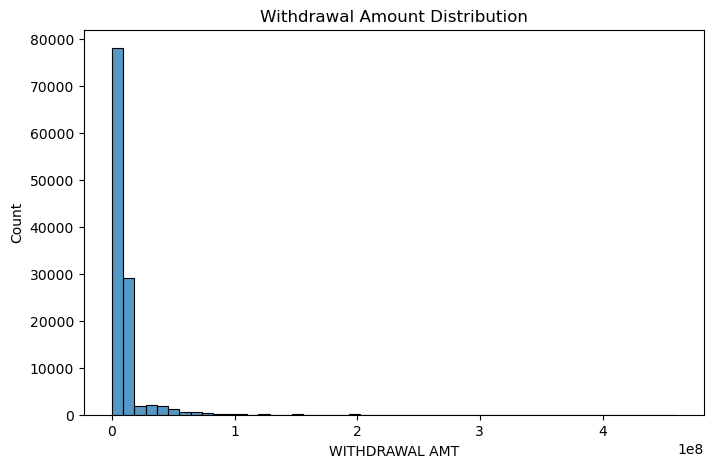

In [60]:
plt.figure(figsize=(8,5))
sns.histplot(df['WITHDRAWAL AMT'], bins=50)
plt.title("Withdrawal Amount Distribution")
plt.show()

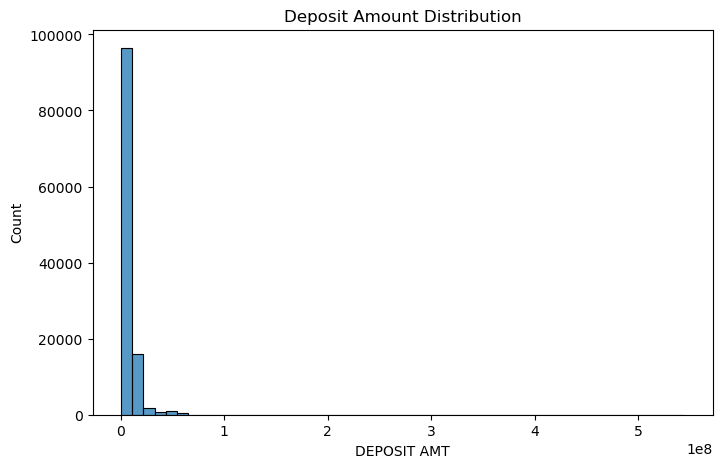

In [61]:
plt.figure(figsize=(8,5))
sns.histplot(df['DEPOSIT AMT'], bins=50)
plt.title("Deposit Amount Distribution")
plt.show()

## Step 8: Balance Analysis

We analyze the account balance to understand how balances change over time.

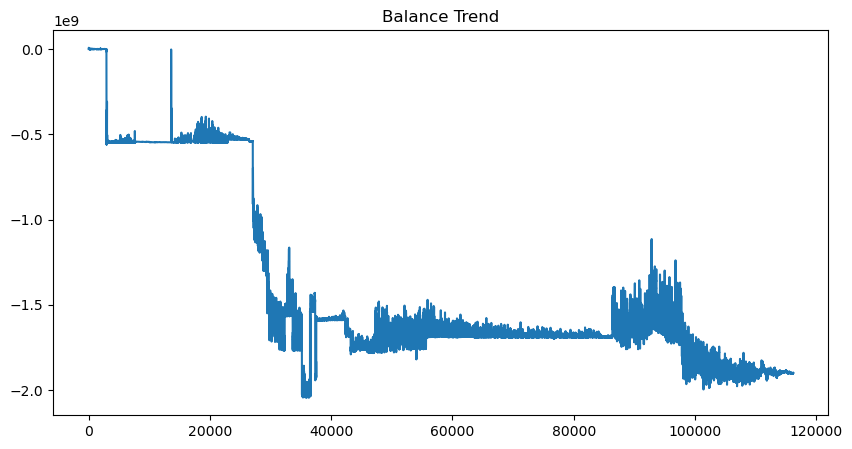

In [62]:
plt.figure(figsize=(10,5))
plt.plot(df['BALANCE AMT'])
plt.title("Balance Trend")
plt.show()

## Step 9: Statistical Test (t-test)

A t-test is performed to determine whether the difference between withdrawals and deposits is statistically significant.

In [63]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(df['WITHDRAWAL AMT'], df['DEPOSIT AMT'])

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 57.15810124988919
P-Value: 0.0


## Step 10: Key Insights

From the analysis we observed:

1. Total deposits and withdrawals across accounts
2. Distribution of transaction amounts
3. Balance trends over time
4. Statistical comparison between withdrawals and deposits